In [8]:
nfile=r"D:\nocare_MS\TEST1\croppedsegment.tif"
swcfile=r"D:\nocare_MS\TEST1\croppedsegment.swc"
tfile=r"D:\nocare_MS\TEST1\croppedsegment.traces"
dz, dy, dx = 0.3, 0.108, 0.108  # Calibration in microns

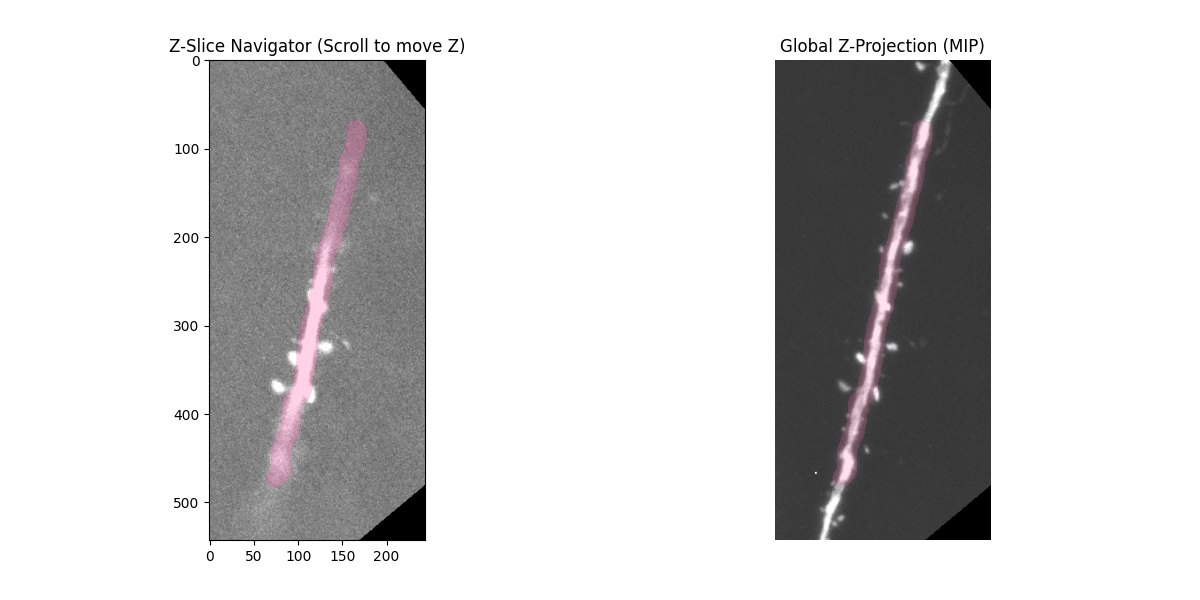

In [ ]:
%matplotlib ipympl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from tifffile import imread
from skimage.filters import gaussian
from scipy.ndimage import distance_transform_edt, label, binary_fill_holes
import ipywidgets as widgets
from IPython.display import display, clear_output

# ==========================================
# 1. LOAD DATA, CALIBRATION & DISTANCE FIELD
# ==========================================
nfile = r"D:\nocare_MS\TEST1\croppedsegment.tif"
swcfile = r"D:\nocare_MS\TEST1\croppedsegment.swc"

dz, dy, dx = 0.3, 0.108, 0.108  
voxel_volume = dx * dy * dz

raw_stack = imread(nfile)

def calculate_distance_field(stack_shape, swc_file):
    """Calculates the 2D distance field once and extrudes it to 3D."""
    swc_data = pd.read_csv(swc_file, sep=r'\s+', comment='#', header=None,
                           names=['id', 'type', 'x', 'y', 'z', 'r', 'parent'])
    
    skeleton_2d = np.zeros((stack_shape[1], stack_shape[2]), dtype=bool)
    for _, row in swc_data.iterrows():
        y_idx = int(round(row['y']/dy))
        x_idx = int(round(row['x']/dx))
        if (0 <= y_idx < stack_shape[1] and 0 <= x_idx < stack_shape[2]):
            skeleton_2d[y_idx, x_idx] = True

    distance_field_2d = distance_transform_edt(~skeleton_2d, sampling=[dy, dx])
    return np.broadcast_to(distance_field_2d, stack_shape).copy()

# Pre-calculate the heavy distance field and base smoothing
dist_field_3d = calculate_distance_field(raw_stack.shape, swcfile)
base_smoothed_stack = gaussian(raw_stack, sigma=1.0, preserve_range=True).astype(raw_stack.dtype)

# ==========================================
# 2. SESSION STATE & UI SETUP
# ==========================================
state = {
    'z': raw_stack.shape[0] // 2,
    'target_x': None, 'target_y': None, 'target_z': None,
    'mask': np.zeros_like(raw_stack, dtype=bool),
    'shaft_barrier': dist_field_3d <= 1.2, # Initialize with default 1.2µm radius
    'saved_targets': [], 
    'target_counter': 1,
    'texts_ax1': [],
    'texts_ax2': []
}

pink_cmap = ListedColormap(['#ff69b4'])
green_cmap = ListedColormap(['#00ff00'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
plt.subplots_adjust(bottom=0.1, top=0.90, left=0.05, right=0.95, wspace=0.1)

# --- AXIS 1: Interactive Z-Viewer ---
img_display = ax1.imshow(raw_stack[state['z']], cmap='gray', vmin=np.percentile(raw_stack, 1), vmax=np.percentile(raw_stack, 99))
barrier_display = ax1.imshow(np.ma.masked_where(~state['shaft_barrier'][state['z']], state['shaft_barrier'][state['z']]), cmap=pink_cmap, alpha=0.3)
mask_display = ax1.imshow(np.ma.masked_where(~state['mask'][state['z']], state['mask'][state['z']]), cmap=green_cmap, alpha=0.6)
target_marker, = ax1.plot([], [], 'c+', markersize=15, markeredgewidth=2)
ax1.set_title("Z-Slice Navigator (Scroll to move Z)")

# --- AXIS 2: MIP Overview ---
mip_raw = np.max(raw_stack, axis=0)
mip_b_initial = np.max(state['shaft_barrier'], axis=0)
ax2.imshow(mip_raw, cmap='gray', vmin=np.percentile(mip_raw, 1), vmax=np.percentile(mip_raw, 99))
mip_barrier_display = ax2.imshow(np.ma.masked_where(~mip_b_initial, mip_b_initial), cmap=pink_cmap, alpha=0.2)
mip_mask_display = ax2.imshow(np.ma.masked_all(mip_raw.shape), cmap=green_cmap, alpha=0.6)
ax2.set_title("Global Z-Projection (MIP)")
ax2.axis('off') 

# --- Widgets ---
z_slider = widgets.IntSlider(value=state['z'], min=0, max=raw_stack.shape[0]-1, description='Z-Slice:', layout=widgets.Layout(width='300px'))
wl_slider = widgets.IntRangeSlider(value=[img_display.get_clim()[0], img_display.get_clim()[1]], min=raw_stack.min(), max=raw_stack.max(), description='Win/Lvl:', layout=widgets.Layout(width='300px'))
barrier_slider = widgets.FloatSlider(value=1.2, min=0.5, max=4.0, step=0.1, description='Barrier µm:', layout=widgets.Layout(width='300px'))
tol_slider = widgets.FloatSlider(value=0.25, min=0.05, max=0.90, step=0.05, description='Tolerance:')

show_targets_cb = widgets.Checkbox(value=True, description='Show Markers', layout=widgets.Layout(width='150px'))
show_mask_cb = widgets.Checkbox(value=True, description='Show Segment', layout=widgets.Layout(width='150px'))

save_target_btn = widgets.Button(description='Save Target (z)', button_style='info', icon='bookmark')
analyze_all_btn = widgets.Button(description='Analyze All Targets', button_style='success', icon='cogs')
target_list_ui = widgets.Select(options=[], description='Target List:', layout={'width': '250px', 'height': '150px'})
log_output = widgets.Output()

# ==========================================
# 3. INTERACTIVE CALLBACKS
# ==========================================
def refresh_display():
    z = state['z']
    img_display.set_data(raw_stack[z])
    
    # Update Barrier on both views
    barrier_z = state['shaft_barrier'][z]
    barrier_display.set_data(np.ma.masked_where(~barrier_z, barrier_z))
    mip_b = np.max(state['shaft_barrier'], axis=0)
    mip_barrier_display.set_data(np.ma.masked_where(~mip_b, mip_b))
    
    if show_mask_cb.value:
        mask_display.set_data(np.ma.masked_where(~state['mask'][z], state['mask'][z]))
        mip_m = np.max(state['mask'], axis=0)
        mip_mask_display.set_data(np.ma.masked_where(~mip_m, mip_m))
    else:
        mask_display.set_data(np.ma.masked_all(raw_stack[z].shape))
        mip_mask_display.set_data(np.ma.masked_all(mip_raw.shape))
    
    for txt in state['texts_ax1']:
        try: txt.remove()
        except: pass
    for txt in state['texts_ax2']:
        try: txt.remove()
        except: pass
    state['texts_ax1'].clear()
    state['texts_ax2'].clear()
    
    if show_targets_cb.value:
        if state['target_z'] == z and state['target_x'] is not None:
            target_marker.set_data([state['target_x']], [state['target_y']])
        else:
            target_marker.set_data([], [])
            
        if state['saved_targets']:
            for t in state['saved_targets']:
                txt1 = ax1.text(t['x'] + 3, t['y'], str(t['idx']), color='yellow', fontsize=10, fontweight='bold')
                state['texts_ax1'].append(txt1)
                txt2 = ax2.text(t['x'] + 3, t['y'], str(t['idx']), color='yellow', fontsize=10, fontweight='bold')
                state['texts_ax2'].append(txt2)
    else:
        target_marker.set_data([], [])
    
    z_slider.unobserve_all()
    z_slider.value = z
    z_slider.observe(lambda c: state.update({'z': c['new']}) or refresh_display(), names='value')
    
    fig.canvas.draw_idle()

def on_barrier_change(change):
    """Instantly updates the barrier mask threshold when the slider moves."""
    state['shaft_barrier'] = dist_field_3d <= change['new']
    refresh_display()

def on_click(event):
    if event.inaxes != ax1 or fig.canvas.toolbar.mode != '': return 
    state['target_x'], state['target_y'], state['target_z'] = int(event.xdata), int(event.ydata), state['z']
    refresh_display()

def on_scroll(event):
    if event.inaxes not in [ax1, ax2]: return
    
    if event.button == 'up':
        new_z = min(state['z'] + 1, raw_stack.shape[0] - 1)
    elif event.button == 'down':
        new_z = max(state['z'] - 1, 0)
    else:
        return
        
    if new_z != state['z']:
        state['z'] = new_z
        refresh_display()

def on_save_target(b=None):
    if state['target_x'] is not None:
        idx = state['target_counter']
        label = f"[{idx}] Z:{state['target_z']} Y:{state['target_y']} X:{state['target_x']}"
        
        if not any(t['z'] == state['target_z'] and t['y'] == state['target_y'] and t['x'] == state['target_x'] for t in state['saved_targets']):
            state['saved_targets'].append({
                'idx': idx, 'label': label, 
                'z': state['target_z'], 'y': state['target_y'], 'x': state['target_x']
            })
            state['target_counter'] += 1
            target_list_ui.options = [t['label'] for t in state['saved_targets']]
            refresh_display() 
            with log_output:
                clear_output()
                print(f"💾 Saved Target {idx}! Total in batch queue: {len(state['saved_targets'])}")

def on_key_press(event):
    if event.key == 'z':
        on_save_target()

def on_target_selected(change):
    if change['new']:
        selected_label = change['new']
        target_data = next((t for t in state['saved_targets'] if t['label'] == selected_label), None)
        if target_data:
            state['target_z'], state['target_y'], state['target_x'] = target_data['z'], target_data['y'], target_data['x']
            state['z'] = target_data['z']
            refresh_display()

def on_analyze_all(b):
    if not state['saved_targets']:
        with log_output: clear_output(); print("⚠️ Queue is empty. Save targets first.")
        return
        
    combined_mask = np.zeros_like(raw_stack, dtype=bool)
    results_list = []
    
    # Generate the masked working image using the current barrier slider value
    current_smoothed_stack = np.where(state['shaft_barrier'], 0, base_smoothed_stack)
    
    with log_output:
        clear_output()
        print(f"⚙️ Batch processing {len(state['saved_targets'])} spines...")
        
        for target in state['saved_targets']:
            z, y, x, idx = target['z'], target['y'], target['x'], target['idx']
            seed_val = current_smoothed_stack[z, y, x]
            
            if seed_val == 0:
                print(f"❌ Target [{idx}] skipped: Seed is inside the pink dendritic barrier.")
                continue
                
            lower_bound = max(seed_val * (1.0 - tol_slider.value), 1e-6)
            
            binary_thresh = current_smoothed_stack >= lower_bound
            labeled_mask, _ = label(binary_thresh)
            seed_label = labeled_mask[z, y, x]
            
            if seed_label == 0:
                print(f"❌ Target [{idx}] skipped: Threshold too strict or point invalid.")
                continue
                
            spine_mask = (labeled_mask == seed_label)
            spine_mask = binary_fill_holes(spine_mask)
            combined_mask = np.logical_or(combined_mask, spine_mask)
            
            voxels = np.sum(spine_mask)
            vol = voxels * voxel_volume
            
            results_list.append({
                'Target_ID': idx, 'Z': z, 'Y': y, 'X': x, 
                'Vol_voxels': voxels, 'Vol_um3': vol
            })
            
    state['mask'] = combined_mask
    global final_results_df 
    final_results_df = pd.DataFrame(results_list)
    
    show_mask_cb.value = True
    refresh_display()
    
    with log_output:
        print(f"✅ Batch Analysis Complete! Segmented {len(final_results_df)} spines.")
        display(final_results_df)

# Wire events
z_slider.observe(lambda c: state.update({'z': c['new']}) or refresh_display(), names='value')
wl_slider.observe(lambda c: img_display.set_clim(c['new'][0], c['new'][1]) or fig.canvas.draw_idle(), names='value')
barrier_slider.observe(on_barrier_change, names='value')

show_targets_cb.observe(lambda c: refresh_display(), names='value')
show_mask_cb.observe(lambda c: refresh_display(), names='value')
target_list_ui.observe(on_target_selected, names='value')

fig.canvas.mpl_connect('button_press_event', on_click)
fig.canvas.mpl_connect('key_press_event', on_key_press)
fig.canvas.mpl_connect('scroll_event', on_scroll)
save_target_btn.on_click(on_save_target)
analyze_all_btn.on_click(on_analyze_all)

# Display Dashboard Layout
toggles = widgets.HBox([show_targets_cb, show_mask_cb])
sliders_col = widgets.VBox([z_slider, wl_slider, barrier_slider, tol_slider, toggles])
buttons = widgets.HBox([save_target_btn, analyze_all_btn])
left_panel = widgets.VBox([sliders_col, buttons, log_output])
display(widgets.HBox([left_panel, target_list_ui]))